# Import

In [51]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


# Plot Accuracy

In [139]:
mode = "visual" #  "image" or "text_only"
with open(f"evaluation_results_with_{mode}.json", "r") as f:
    evaluation_data = json.load(f)

In [140]:
# Build DataFrames from the new evaluation_results.json structure
eval_rows = []
group_rows = []

for level_str, stats in evaluation_data.items():
    level = int(level_str)
    eval_rows.append({
        "level": level,
        "correct": stats.get("correct", 0),
        "total": stats.get("total", 0),
        "acc": stats.get("acc", 0.0),
    })

    by_group = stats.get("by_rel_group", {}) or {}
    for g_name, g_stats in by_group.items():
        group_rows.append({
            "level": level,
            "rel_group": g_name,
            "correct": g_stats.get("correct", 0),
            "total": g_stats.get("total", 0),
            "acc": g_stats.get("acc", 0.0),
        })

eval_df = pd.DataFrame(eval_rows).sort_values("level").reset_index(drop=True)
group_df = pd.DataFrame(group_rows).sort_values(["level", "rel_group"]).reset_index(drop=True)

# Labels for plotting
eval_df["level_label"] = eval_df["level"].apply(lambda k: f"level {k}")
if not group_df.empty:
    group_df["level_label"] = group_df["level"].apply(lambda k: f"level {k}")

eval_df.head()

,level,correct,total,acc,level_label
0,0,81,160,50.625000,level 0
1,1,82,160,51.250000,level 1
2,2,169,296,57.094595,level 2
3,3,487,920,52.934783,level 3
4,4,962,1836,52.396514,level 4


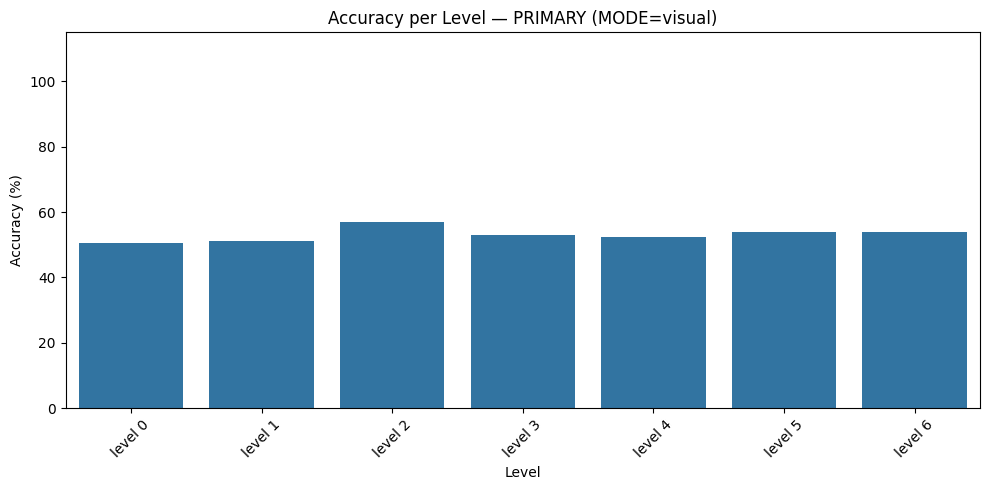

In [141]:
# Plot 2a: PRIMARY
primary_df = group_df[group_df["rel_group"] == "PRIMARY"]

if not primary_df.empty:
    plt.figure(figsize=(10, 5))
    ax_p = sns.barplot(
        data=primary_df,
        x="level_label",
        y="acc"
    )

    plt.xlabel("Level")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Accuracy per Level — PRIMARY (MODE={mode})")
    plt.ylim(0, 115)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"accuracy_primary_{mode}.png")
    plt.show()
else:
    print("No PRIMARY data found")


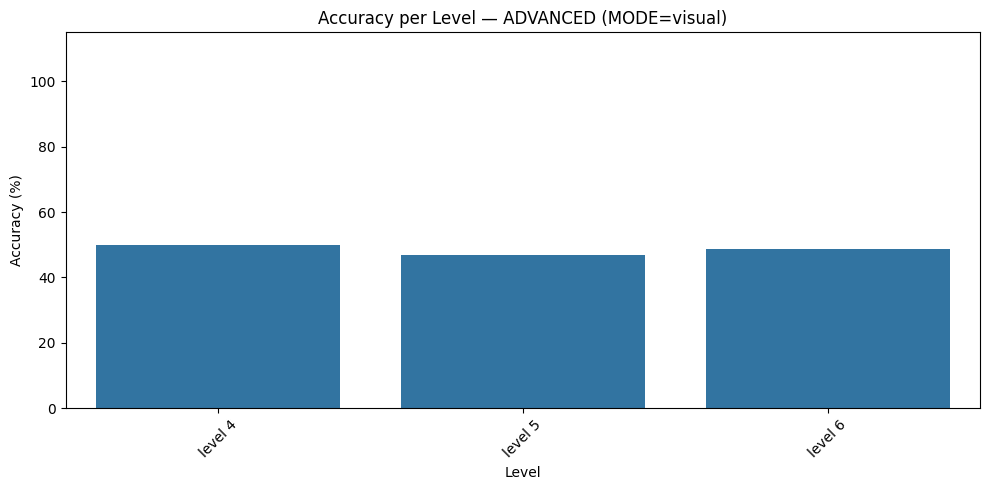

In [144]:
# Plot 2b: ADVANCED
advanced_df = group_df[group_df["rel_group"] == "ADVANCED"]

if not advanced_df.empty:
    plt.figure(figsize=(10, 5))
    ax_a = sns.barplot(
        data=advanced_df,
        x="level_label",
        y="acc"
    )

    # Label only zero-accuracy bars (n=0 cases)
    for i, p in enumerate(ax_a.patches):
        height = p.get_height()
        if height == 0:
            ax_a.text(
                p.get_x() + p.get_width() / 2,
                height + 1,
                "n=0",
                ha="center",
                fontsize=9,
                fontweight="bold"
            )

    plt.xlabel("Level")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Accuracy per Level — ADVANCED (MODE={mode})")
    plt.ylim(0, 115)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"accuracy_advanced_{mode}.png")
    plt.show()
else:
    print("No ADVANCED data found")


In [143]:
# Optional: view per-group table
group_df

,level,rel_group,correct,total,acc,level_label
0,0,PRIMARY,81,160,50.625000,level 0
1,1,PRIMARY,82,160,51.250000,level 1
2,2,PRIMARY,169,296,57.094595,level 2
3,3,PRIMARY,487,920,52.934783,level 3
4,4,ADVANCED,8,16,50.000000,level 4
5,4,PRIMARY,954,1820,52.417582,level 4
6,5,ADVANCED,120,256,46.875000,level 5
7,5,PRIMARY,939,1744,53.841743,level 5
8,6,ADVANCED,112,230,48.695652,level 6
9,6,PRIMARY,953,1770,53.841808,level 6


# Reading Logs

In [148]:
mode = "visual"
logs_df = pd.read_csv(f"./model_calls_log_with_{mode}.csv")
print(logs_df.head(5))
# print(list(logs_df[(logs_df["Model_Prediction"] == "no") & (logs_df["Ground_Truth"] == "yes")]['Prompt']))
mask = logs_df["Model_Prediction"].str.strip().str.lower() != logs_df["Ground_Truth"].str.strip().str.lower()
print(len(logs_df[mask]))

             Timestamp  Level  \
0  2025-12-23 15:12:00      0   
1  2025-12-23 15:12:01      0   
2  2025-12-23 15:12:01      0   
3  2025-12-23 15:12:01      0   
4  2025-12-23 15:12:01      0   

                                          Image_Path Rel_Group Rel_Type  \
0  /home/kkarthikeyan/deep-learning/DeepLearningP...   PRIMARY    above   
1  /home/kkarthikeyan/deep-learning/DeepLearningP...   PRIMARY    below   
2  /home/kkarthikeyan/deep-learning/DeepLearningP...   PRIMARY    below   
3  /home/kkarthikeyan/deep-learning/DeepLearningP...   PRIMARY    above   
4  /home/kkarthikeyan/deep-learning/DeepLearningP...   PRIMARY  left_of   

                                              Prompt Completion  Confidence  \
0  USER: <image>\nIs the yellow square above the ...        Yes    0.899121   
1  USER: <image>\nIs the yellow square below the ...        Yes    0.914901   
2  USER: <image>\nIs the pink star below the yell...        Yes    0.962673   
3  USER: <image>\nIs the pink star

In [149]:
import textwrap

df_bad = logs_df[mask].reset_index(drop=True)

def wrap(s, width=110):
    return textwrap.fill("" if pd.isna(s) else str(s), width=width)

for i, row in enumerate(df_bad.itertuples(index=False), start=1):
    print("\n" + "=" * 120)
    gt = getattr(row, "Ground_Truth", "")
    pred = getattr(row, "Model_Prediction", "")
    conf = getattr(row, "Confidence", "")
    print(f"[{i}] GT={gt}  PRED={pred}  CONF={conf}")
    print("-" * 120)

    prompt = getattr(row, "Prompt", "")
    completion = getattr(row, "Completion", "")

    print("PROMPT:\n" + wrap(prompt))
    print("\nCOMPLETION:\n" + wrap(completion))


[1] GT=no  PRED=yes  CONF=0.9149008872388792
------------------------------------------------------------------------------------------------------------------------
PROMPT:
USER: <image> Is the yellow square below the pink star? ASSISTANT: MODEL: Yes

COMPLETION:
Yes

[2] GT=no  PRED=yes  CONF=0.9658995543235224
------------------------------------------------------------------------------------------------------------------------
PROMPT:
USER: <image> Is the pink star above the yellow square? ASSISTANT: MODEL: Yes

COMPLETION:
Yes

[3] GT=no  PRED=yes  CONF=0.7931058073161854
------------------------------------------------------------------------------------------------------------------------
PROMPT:
USER: <image> Is the purple square right of the cyan circle? ASSISTANT: MODEL: Yes

COMPLETION:
Yes

[4] GT=no  PRED=yes  CONF=0.8175744103219862
------------------------------------------------------------------------------------------------------------------------
PROMPT:
USER: <ima

In [150]:
logs_df["Model_Prediction"].value_counts(dropna=False)

Model_Prediction
yes    7115
no      257
Name: count, dtype: int64

In [151]:
logs_df["Ground_Truth"].value_counts(dropna=False)

Ground_Truth
yes    3686
no     3686
Name: count, dtype: int64

## Plot Confusion Matrix

In [152]:
def generate_confusion_matrix(csv_file, output_image='confusion_matrix.png'):
    # 1. Load the data
    df = pd.read_csv(csv_file)

    # 2. Clean and Normalize labels (handling whitespace/case)
    y_true = df['Ground_Truth'].str.strip().str.lower()
    y_pred = df['Model_Prediction'].str.strip().str.lower()

    # 3. Compute Confusion Matrix
    # We explicitly set labels to ensure the order is consistent
    labels = ['yes', 'no']
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # 4. Plotting using Seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted Yes', 'Predicted No'], 
                yticklabels=['Actual Yes', 'Actual No'])

    plt.title(f'VLM Relational Reasoning Confusion Matrix (MODE={mode})')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')

    # 5. Save and Show
    plt.savefig(output_image, bbox_inches='tight', dpi=300)
    print(f"Confusion matrix saved to {output_image}")
    plt.show()

Confusion matrix saved to confusion_matrix.png


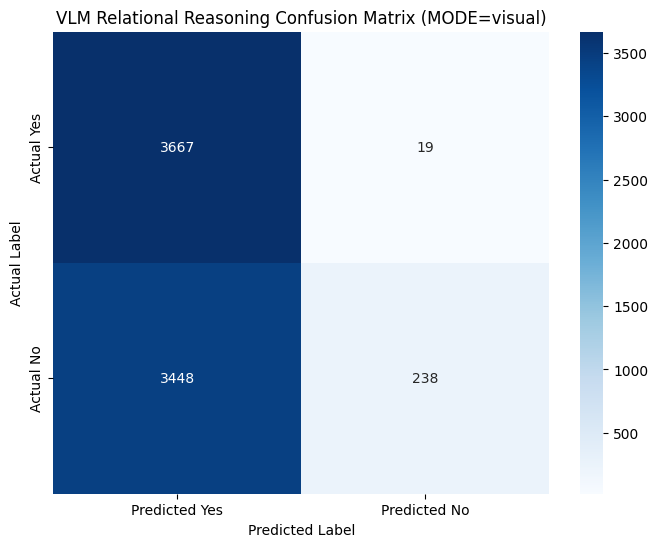

In [153]:
generate_confusion_matrix(f"./model_calls_log_with_{mode}.csv")